In [2]:
# type: ignore
import numpy as np

import pandas as pd

import seaborn as sns

import mesa

from mesa.discrete_space import CellAgent, OrthogonalVonNeumannGrid

import random

import time

from matplotlib.colors import ListedColormap

from collections import deque

import diccionario_movimientos

In [3]:
#type: ignore
#Funcion "breadth_first_search" que llamaremos para calcular la ruta que debe tomar el agente "Carro" para llegar de un punto a otro
# Esta misma funcion se llamara nuevamente en caso de que el agente Carro encuentre un obstaculo.

def breadth_first_search(start: tuple, goal: tuple, grid: OrthogonalVonNeumannGrid) -> list[tuple]:
    queue: deque[tuple] = deque()
    visited: set[tuple] = set()
    parent: dict[tuple, tuple] = {}

    queue.append(start)
    visited.add(start)

    while queue:
        current: tuple = queue.popleft()
        if current == goal:
            path = []
            while current in parent:
                path.append(current)
                current = parent[current]
            path.append(start)
            path.pop(-1)
            return path[::-1]
        
        cell = grid[current].coordinate
        neighbors = diccionario_movimientos.movimientos_posibles[cell[0] + 1][cell[1] + 1]

        for i in neighbors:
            cell_pos = (i[0] - 1, i[1] - 1)
            if cell_pos not in visited:
                visited.add(cell_pos)
                parent[cell_pos] = current
                queue.append(cell_pos)
    return []

In [4]:
# type: ignore
# Clase "AgenteCalle" que tenga valores de dirección asociados, para marcar la circulación.

class AgenteCalle(CellAgent):
    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell
        self.isBuilding = False

    def step(self):
        pass

In [5]:
# type: ignore
# Agente "Semaforo"

class Semaforo(CellAgent):
    def __init__(self, model, cell):     
        super().__init__(model)
        self.cell = cell
        self.avanza = False
        self.contador = 0

    def cambair_estado(self):
        self.avanza = not self.avanza

    def step(self):
        self.contador += 1
        if self.contador >= 10:
            self.cambair_estado()
            self.contador = 0

In [6]:
# type: ignore
# Agente "Carro"

class Carro(CellAgent):
    def __init__(self, model, cell):
        super().__init__(model)
        self.cell = cell
        self.destino = None
        self.estacionado = False
        self.ruta = []

    def calcular_ruta(self):
        self.ruta = breadth_first_search(self.cell.coordinate, self.destino, self.model.grid)

    def puede_avanzar(self):
        siguiente_celda = self.obtener_siguiente()
        if not siguiente_celda:
            return False
        for agente in siguiente_celda.agents:
            if isinstance(agente, Carro):
                return False
            if isinstance(agente, Semaforo):
                if not agente.avanza:
                    return False
        return True

    def avanzar(self):
        siguiente_celda = self.obtener_siguiente()
        if siguiente_celda:
            self.cell = siguiente_celda
            self.ruta.pop(0)

    def detenerse(self):
        pass

    def obtener_siguiente(self):
        if not self.ruta:
            return None
        siguiente_pos = self.ruta[0]
        siguiente_celda = self.model.grid[siguiente_pos]
        return siguiente_celda
    
    def cambiar_carril(self):
        pass
    
    def llego_destino(self):
        return self.cell.coordinate == self.destino

    def estacionarse(self):
        self.estacionado = True

    def step(self):
        if not self.estacionado:
            if self.puede_avanzar():
                self.avanzar()
            else:
                self.detenerse()
        if self.llego_destino():
            self.estacionarse()

In [7]:
# type: ignore
# Modelo

class TrafficModel(mesa.Model):
    def __init__(self):
        super().__init__()
        self.grid = OrthogonalVonNeumannGrid((24, 24), torus = False, capacity = 100)

        # Create street agents for the grid
        for x in range(width):
            for y in range(height):
                cell = self.grid[(x, y)]
                calle = AgenteCalle(self, cell)
        
                #Set Buildings
                if ((1 < x < 4) and (1 < y < 4) or
                    (1 < x < 4) and (5 < y < 8) or
                    (1 < x < 4) and (11 < y < 16) or
                    (1 < x < 8) and (17 < y < 22) or
                    (5 < x < 8) and (1 < y < 4) or
                    (5 < x < 8) and (5 < y < 8) or
                    (5 < x < 8) and (11 < y < 16) or
                    (11 < x < 22) and (1 < y < 4) or
                    (11 < x < 22) and (5 < y < 8) or
                    (11 < x < 16) and (11 < y < 15) or
                    (11 < x < 16) and (16 < y < 22) or
                    (17 < x < 22) and (11 < y < 22)):
                    calle.isBuilding = True
        
        # Create one car for testing
        start_cell = self.grid[(0, 0)]
        carro = Carro(self, start_cell)
        carro.destino = (18 - 1, 2 - 1)  # Set destination to opposite corner
        carro.calcular_ruta()

        semaforo = Semaforo(self, self.grid[(21, 4)])
        
    def step(self):
        # Execute one step for all agents
        for agent in self.agents:
            agent.step()

Testing Carro agent with visualization...
Starting position: (0, 0)
Destination: (17, 1)
Route length: 48
Step 1: Position (0, 1), Remaining route: 47
Step 2: Position (0, 2), Remaining route: 46


c:\Users\Adria\AppData\Local\Programs\Python\Python313\Lib\site-packages\mesa\discrete_space\grid.py:101: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  super().__init__(capacity=capacity, random=random, cell_klass=cell_klass)


Step 3: Position (0, 3), Remaining route: 45
Step 4: Position (0, 4), Remaining route: 44
Step 5: Position (0, 5), Remaining route: 43
Step 6: Position (0, 6), Remaining route: 42
Step 7: Position (0, 7), Remaining route: 41
Step 8: Position (0, 8), Remaining route: 40
Step 9: Position (0, 9), Remaining route: 39
Step 10: Position (0, 10), Remaining route: 38
Step 11: Position (0, 11), Remaining route: 37
Step 12: Position (1, 11), Remaining route: 36
Step 13: Position (2, 11), Remaining route: 35
Step 14: Position (3, 11), Remaining route: 34
Step 15: Position (4, 11), Remaining route: 33
Step 16: Position (5, 11), Remaining route: 32
Step 17: Position (6, 11), Remaining route: 31
Step 18: Position (7, 11), Remaining route: 30
Step 19: Position (8, 11), Remaining route: 29
Step 20: Position (9, 11), Remaining route: 28
Step 21: Position (10, 11), Remaining route: 27
Step 22: Position (11, 11), Remaining route: 26
Step 23: Position (11, 10), Remaining route: 25
Step 24: Position (11, 9

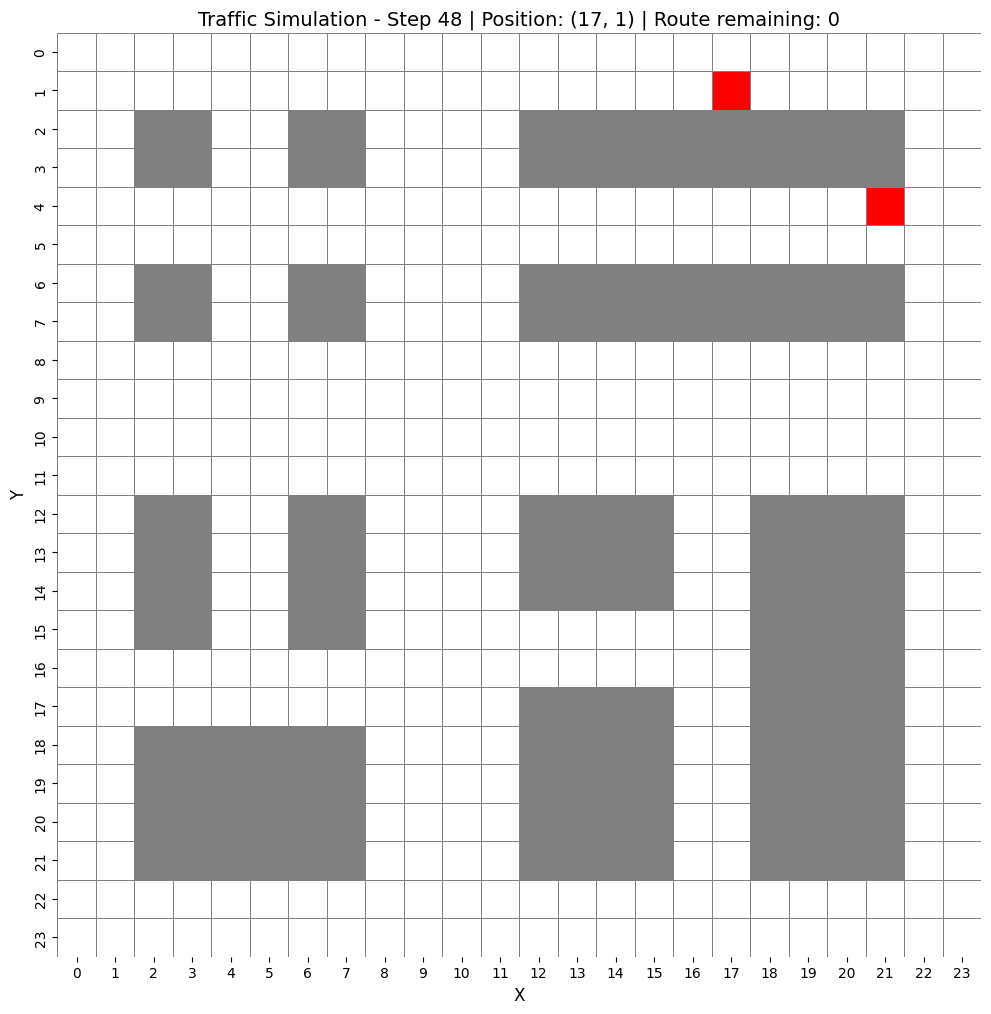

In [9]:
#type: ignore
import matplotlib.pyplot as plt

print("Testing Carro agent with visualization...")

# Create the model
width = 24
height = 24
model = TrafficModel()

# Get the car agent
carro = [agent for agent in model.agents if isinstance(agent, Carro)][0]

print(f"Starting position: {carro.cell.coordinate}")
print(f"Destination: {carro.destino}")
print(f"Route length: {len(carro.ruta)}")

plt.ion()

# Create figure and axis once
fig, ax = plt.subplots(figsize=(12, 12))

def get_grid_state():
    """Create a grid showing car position"""
    grid_state = np.zeros((height, width))
    
    # Mark buildings (grey)
    for cell in model.grid.all_cells:
        calle_agents = [agent for agent in cell.agents if isinstance(agent, AgenteCalle)]
        if calle_agents and calle_agents[0].isBuilding:
            x, y = cell.coordinate
            grid_state[y, x] = 4  # Buildings
    
    #Semaforos
    for cell in model.grid.all_cells:
        semaforo_agent = [agent for agent in cell.agents if isinstance(agent, Semaforo)]
        if semaforo_agent and semaforo_agent[0].avanza:
            x, y = cell.coordinate
            grid_state[y, x] = 5
        elif semaforo_agent and not semaforo_agent[0].avanza:
            x, y = cell.coordinate
            grid_state[y, x] = 3
    
    # # Mark the route
    # for pos in carro.ruta:
    #     grid_state[pos[1], pos[0]] = 1  # Planned route
    
    # Mark the destination
    dest_x, dest_y = carro.destino
    grid_state[dest_y, dest_x] = 3  # Destination
    
    # Mark the car's position (last so it's on top)
    if not carro.estacionado:
        x, y = carro.cell.coordinate
        grid_state[y, x] = 2  # Car position
    
    return grid_state

# Create custom colormap
colors = ['white', 'lightblue', 'blue', 'red', 'grey', 'green']
cmap = ListedColormap(colors)

step_counter = 0
max_steps = 100

while not carro.estacionado and step_counter < max_steps:
    model.step()  # This will update all agents including the semaforo
    step_counter += 1
    
    # Calculate grid state
    grid_state = get_grid_state()
    
    # Clear previous plot
    ax.clear()
    
    # Draw updated heatmap
    sns.heatmap(grid_state, cmap=cmap, vmin=0, vmax=5,
                square=True, linewidths=0.5, linecolor='gray',
                cbar=False, ax=ax, annot=False)
    
    ax.set_title(f'Traffic Simulation - Step {step_counter} | Position: {carro.cell.coordinate} | Route remaining: {len(carro.ruta)}', fontsize=14)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    
    print(f"Step {step_counter}: Position {carro.cell.coordinate}, Remaining route: {len(carro.ruta)}")
    
    # Update display without blocking
    fig.canvas.draw()
    fig.canvas.flush_events()
    
    time.sleep(0.01)  # Add delay to see the animation

if carro.estacionado:
    print(f"\nCar reached destination in {step_counter} steps!")
else:
    print(f"\nCar did not reach destination after {max_steps} steps.")

# Keep final plot open
plt.ioff()
plt.show()